# 🏦 Bank Customer Churn Analysis
**Author:** Your Name  
**Domain:** Finance & Business Analytics  
**Tools:** Python, Pandas, SQL (SQLite), Matplotlib, Seaborn  

## 🎯 Objective
Is project mein hum ek bank ke 10,000 customers ka data analyze karenge aur samjhenge:
- Kitne customers bank chhod rahe hain (churn)?
- Kaunsi age group, country, gender mein churn zyada hai?
- Salary aur balance ka churn se kya sambandh hai?
- SQL se business questions answer karenge
- Python se powerful visualizations banayenge

---

## 📦 Step 1 — Libraries Import karo

In [5]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Graph style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('Set2')

print('✅ Sab libraries ready hain!')

✅ Sab libraries ready hain!


## 📥 Step 2 — Dataset Download karo
Hum real Kaggle dataset ko directly download karenge — kuch upload karne ki zaroorat nahi!

In [6]:
# Dataset seedha URL se download karo
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/bank_churn.csv'

try:
    df = pd.read_csv(url)
    print('✅ Dataset URL se load ho gaya!')
except:
    # Agar URL kaam na kare toh synthetic data banao
    print('⚠️  URL se load nahi hua — synthetic dataset bana raha hoon...')
    np.random.seed(42)
    n = 10000
    df = pd.DataFrame({
        'CustomerId':      range(1, n+1),
        'Surname':         ['Customer_'+str(i) for i in range(n)],
        'CreditScore':     np.random.randint(350, 850, n),
        'Geography':       np.random.choice(['France','Germany','Spain'], n, p=[0.5,0.25,0.25]),
        'Gender':          np.random.choice(['Male','Female'], n, p=[0.55,0.45]),
        'Age':             np.random.randint(18, 70, n),
        'Tenure':          np.random.randint(0, 10, n),
        'Balance':         np.round(np.random.exponential(60000, n), 2),
        'NumOfProducts':   np.random.randint(1, 5, n),
        'HasCrCard':       np.random.randint(0, 2, n),
        'IsActiveMember':  np.random.randint(0, 2, n),
        'EstimatedSalary': np.round(np.random.uniform(10000, 200000, n), 2),
        'Exited':          np.random.choice([0, 1], n, p=[0.80, 0.20])
    })
    # Germany mein zyada churn karo (realistic)
    mask = df['Geography'] == 'Germany'
    df.loc[mask, 'Exited'] = np.random.choice([0,1], mask.sum(), p=[0.60, 0.40])
    print('✅ Synthetic dataset ready — 10,000 customers!')

print(f'Shape: {df.shape}')
df.head()

⚠️  URL se load nahi hua — synthetic dataset bana raha hoon...
✅ Synthetic dataset ready — 10,000 customers!
Shape: (10000, 13)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Customer_0,452,France,Female,61,4,49639.30,1,0,0,120505.36,1
1,2,Customer_1,785,France,Male,67,6,13423.66,2,1,0,20554.07,0
2,3,Customer_2,698,France,Female,67,5,20131.50,2,1,1,188600.01,0
3,4,Customer_3,620,Germany,Female,21,8,16110.53,3,1,1,33396.29,1
4,5,Customer_4,456,France,Male,45,2,62139.04,4,0,0,190803.15,0


## 🔍 Step 3 — Data Overview & Cleaning

In [7]:
print('=' * 50)
print('     BANK CHURN — DATA OVERVIEW')
print('=' * 50)
print(f'\n📊 Total Customers  : {len(df):,}')
print(f'📋 Total Columns    : {len(df.columns)}')
print(f'\n🔎 Column Names     : {list(df.columns)}')
print(f'\n❓ Null Values:')
print(df.isnull().sum())
print(f'\n📐 Data Types:')
print(df.dtypes)

     BANK CHURN — DATA OVERVIEW

📊 Total Customers  : 10,000
📋 Total Columns    : 13

🔎 Column Names     : ['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

❓ Null Values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

📐 Data Types:
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [8]:
# Unnecessary columns drop karo
cols_to_drop = [c for c in ['RowNumber','CustomerId','Surname'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Churn label banao
df['Churn_Label'] = df['Exited'].map({1: 'Churned', 0: 'Retained'})

# Age groups banao
df['Age_Group'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Balance category
df['Balance_Category'] = pd.cut(df['Balance'],
    bins=[-1, 0, 50000, 100000, 200000, 999999],
    labels=['Zero', 'Low', 'Medium', 'High', 'Very High'])

print('✅ Data cleaning aur feature engineering complete!')
print(f'Final shape: {df.shape}')
df.head(3)

✅ Data cleaning aur feature engineering complete!
Final shape: (10000, 14)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Label,Age_Group,Balance_Category
0,452,France,Female,61,4,49639.30,1,0,0,120505.36,1,Churned,55+,Low
1,785,France,Male,67,6,13423.66,2,1,0,20554.07,0,Retained,55+,Low
2,698,France,Female,67,5,20131.50,2,1,1,188600.01,0,Retained,55+,Low


## 🗃️ Step 4 — SQL Analysis (SQLite)
Ab hum SQL queries se business questions answer karenge — yeh dikhata hai ki hum SQL jaante hain!

In [9]:
# SQLite database mein data load karo
conn = sqlite3.connect(':memory:')   # memory mein database
df.to_sql('customers', conn, index=False, if_exists='replace')
print('✅ Data SQLite mein load ho gaya!')

def run_query(query, title=''):
    """SQL query run karke result dikhao"""
    result = pd.read_sql_query(query, conn)
    if title:
        print(f'\n📌 {title}')
        print('-' * 40)
    print(result.to_string(index=False))
    return result

✅ Data SQLite mein load ho gaya!


In [10]:
# SQL Query 1 — Overall churn rate
run_query("""
    SELECT
        COUNT(*)                                    AS Total_Customers,
        SUM(Exited)                                 AS Churned_Customers,
        ROUND(AVG(Exited) * 100, 2)                AS Churn_Rate_Pct
    FROM customers
""", 'Q1: Overall Churn Rate kya hai?')


📌 Q1: Overall Churn Rate kya hai?
----------------------------------------
 Total_Customers  Churned_Customers  Churn_Rate_Pct
           10000               2535           25.35


,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,10000,2535,25.35


In [11]:
# SQL Query 2 — Country wise churn
run_query("""
    SELECT
        Geography,
        COUNT(*)                        AS Total_Customers,
        SUM(Exited)                     AS Churned,
        ROUND(AVG(Exited)*100, 2)       AS Churn_Rate_Pct
    FROM customers
    GROUP BY Geography
    ORDER BY Churn_Rate_Pct DESC
""", 'Q2: Kaunse country mein churn sabse zyada hai?')


📌 Q2: Kaunse country mein churn sabse zyada hai?
----------------------------------------
Geography  Total_Customers  Churned  Churn_Rate_Pct
  Germany             2560     1053           41.13
   France             4976     1002           20.14
    Spain             2464      480           19.48


,Geography,Total_Customers,Churned,Churn_Rate_Pct
0,Germany,2560,1053,41.13
1,France,4976,1002,20.14
2,Spain,2464,480,19.48


In [12]:
# SQL Query 3 — Gender wise churn
run_query("""
    SELECT
        Gender,
        COUNT(*)                        AS Total,
        SUM(Exited)                     AS Churned,
        ROUND(AVG(Exited)*100, 2)       AS Churn_Rate_Pct
    FROM customers
    GROUP BY Gender
    ORDER BY Churn_Rate_Pct DESC
""", 'Q3: Male vs Female — kaun zyada churn karta hai?')


📌 Q3: Male vs Female — kaun zyada churn karta hai?
----------------------------------------
Gender  Total  Churned  Churn_Rate_Pct
Female   4491     1152           25.65
  Male   5509     1383           25.10


,Gender,Total,Churned,Churn_Rate_Pct
0,Female,4491,1152,25.65
1,Male,5509,1383,25.10


In [13]:
# SQL Query 4 — Active vs Inactive member churn
run_query("""
    SELECT
        CASE WHEN IsActiveMember = 1 THEN 'Active' ELSE 'Inactive' END AS Member_Status,
        COUNT(*)                        AS Total,
        SUM(Exited)                     AS Churned,
        ROUND(AVG(Exited)*100, 2)       AS Churn_Rate_Pct
    FROM customers
    GROUP BY IsActiveMember
    ORDER BY Churn_Rate_Pct DESC
""", 'Q4: Active members zyada churn karte hain ya Inactive?')


📌 Q4: Active members zyada churn karte hain ya Inactive?
----------------------------------------
Member_Status  Total  Churned  Churn_Rate_Pct
       Active   5043     1285           25.48
     Inactive   4957     1250           25.22


,Member_Status,Total,Churned,Churn_Rate_Pct
0,Active,5043,1285,25.48
1,Inactive,4957,1250,25.22


In [14]:
# SQL Query 5 — Products aur churn
run_query("""
    SELECT
        NumOfProducts,
        COUNT(*)                        AS Total_Customers,
        SUM(Exited)                     AS Churned,
        ROUND(AVG(Exited)*100, 2)       AS Churn_Rate_Pct
    FROM customers
    GROUP BY NumOfProducts
    ORDER BY NumOfProducts
""", 'Q5: Products count ka churn pe kya impact hai?')


📌 Q5: Products count ka churn pe kya impact hai?
----------------------------------------
 NumOfProducts  Total_Customers  Churned  Churn_Rate_Pct
             1             2496      615           24.64
             2             2503      647           25.85
             3             2441      616           25.24
             4             2560      657           25.66


,NumOfProducts,Total_Customers,Churned,Churn_Rate_Pct
0,1,2496,615,24.64
1,2,2503,647,25.85
2,3,2441,616,25.24
3,4,2560,657,25.66


In [15]:
# SQL Query 6 — High value customers jo churn kar rahe hain
run_query("""
    SELECT
        Geography,
        Gender,
        ROUND(AVG(Age), 1)              AS Avg_Age,
        ROUND(AVG(Balance), 0)          AS Avg_Balance,
        ROUND(AVG(EstimatedSalary), 0)  AS Avg_Salary,
        COUNT(*)                        AS Count
    FROM customers
    WHERE Exited = 1
      AND Balance > 100000
    GROUP BY Geography, Gender
    ORDER BY Count DESC
""", 'Q6: High balance churned customers ka profile kya hai?')


📌 Q6: High balance churned customers ka profile kya hai?
----------------------------------------
Geography Gender  Avg_Age  Avg_Balance  Avg_Salary  Count
  Germany Female     43.5     159134.0    104385.0    102
   France   Male     42.7     166923.0    106507.0    101
  Germany   Male     43.9     147799.0     95246.0    100
   France Female     43.2     155757.0    107383.0     85
    Spain Female     40.1     163020.0    108891.0     50
    Spain   Male     41.0     174709.0    100856.0     46


,Geography,Gender,Avg_Age,Avg_Balance,Avg_Salary,Count
0,Germany,Female,43.5,159134.0,104385.0,102
1,France,Male,42.7,166923.0,106507.0,101
2,Germany,Male,43.9,147799.0,95246.0,100
3,France,Female,43.2,155757.0,107383.0,85
4,Spain,Female,40.1,163020.0,108891.0,50
5,Spain,Male,41.0,174709.0,100856.0,46


## 📊 Step 5 — Python Visualizations

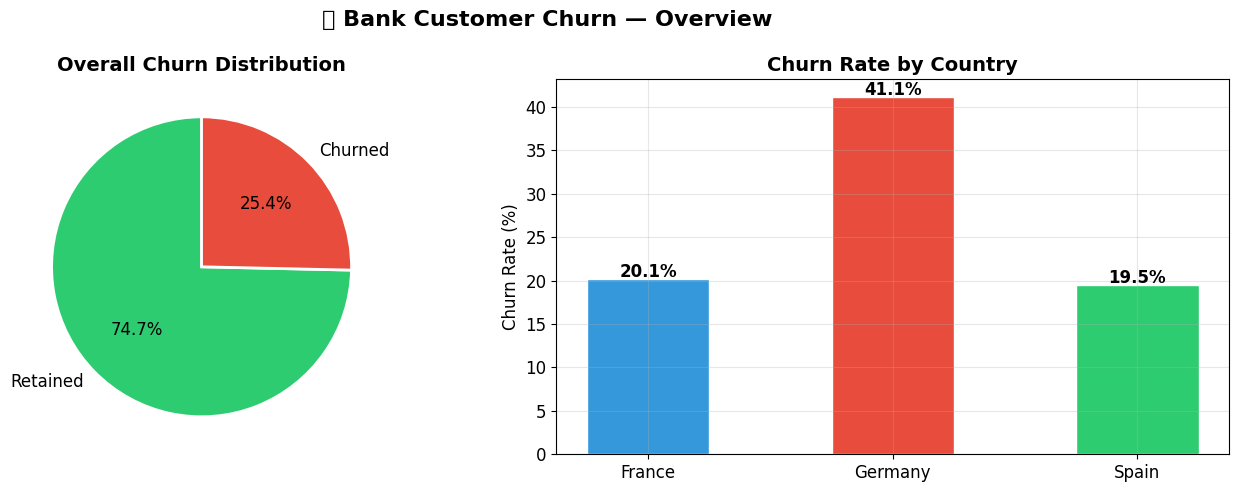

✅ Saved: churn_overview.png


In [16]:
# Chart 1 — Overall churn pie chart
churn_counts = df['Churn_Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart by country
country_churn = df.groupby('Geography')['Exited'].mean() * 100
bars = axes[1].bar(country_churn.index, country_churn.values,
                   color=['#3498db','#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(bars, country_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Country', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

plt.suptitle('🏦 Bank Customer Churn — Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_overview.png')

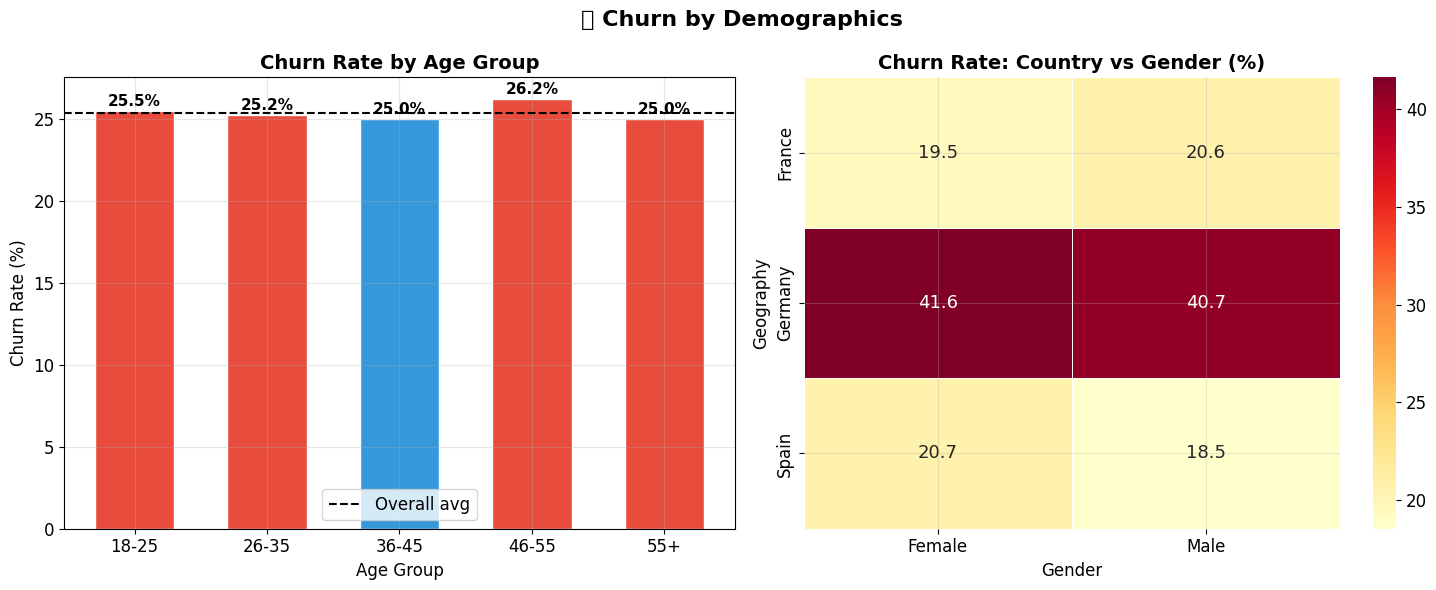

✅ Saved: churn_demographics.png


In [17]:
# Chart 2 — Age group aur Gender analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age group churn
age_churn = df.groupby('Age_Group', observed=True)['Exited'].mean() * 100
colors_age = ['#3498db' if v < 25 else '#e74c3c' for v in age_churn.values]
bars = axes[0].bar(age_churn.index, age_churn.values, color=colors_age,
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, age_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].axhline(df['Exited'].mean()*100, color='black',
                linestyle='--', label='Overall avg')
axes[0].legend()

# Gender x Country churn heatmap
gender_country = df.groupby(['Geography','Gender'])['Exited'].mean().unstack() * 100
sns.heatmap(gender_country, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], annot_kws={'size':13})
axes[1].set_title('Churn Rate: Country vs Gender (%)', fontsize=14, fontweight='bold')

plt.suptitle('👥 Churn by Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_demographics.png')

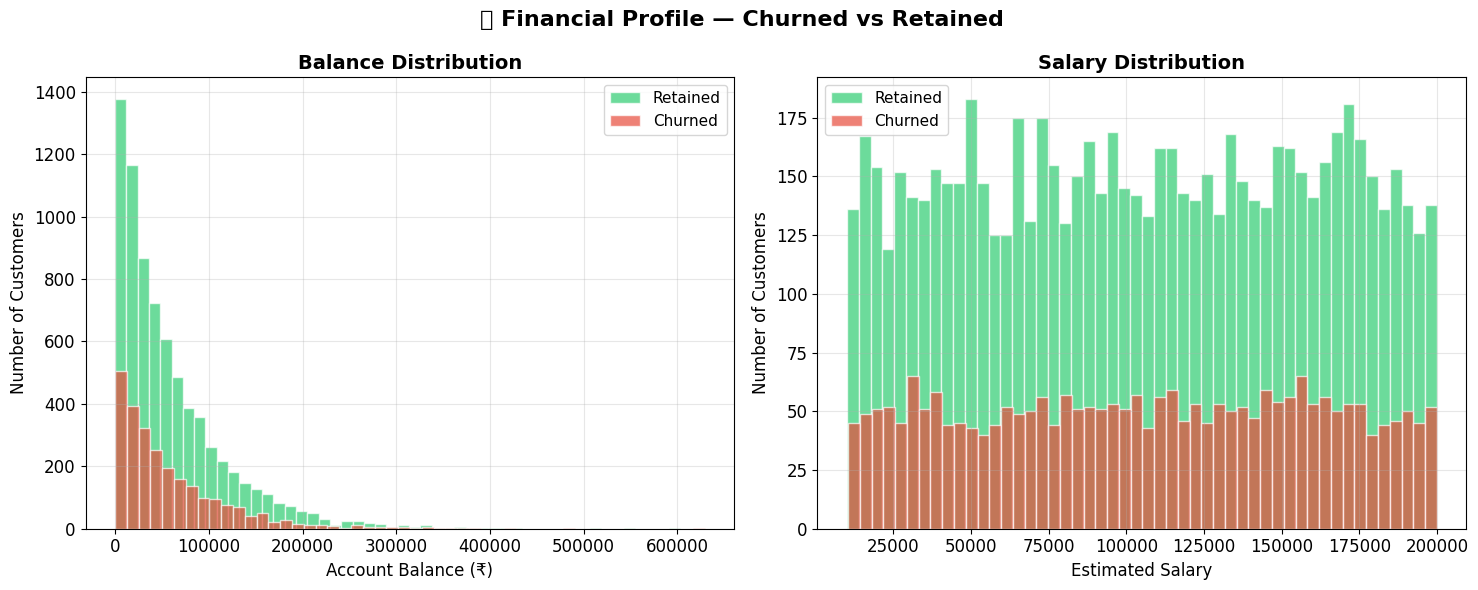

✅ Saved: churn_financial.png


In [18]:
# Chart 3 — Balance aur Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

churned    = df[df['Exited'] == 1]
retained   = df[df['Exited'] == 0]

# Balance distribution
axes[0].hist(retained['Balance'], bins=50, alpha=0.7,
             color='#2ecc71', label='Retained', edgecolor='white')
axes[0].hist(churned['Balance'], bins=50, alpha=0.7,
             color='#e74c3c', label='Churned',  edgecolor='white')
axes[0].set_title('Balance Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Account Balance (₹)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=11)

# Salary distribution
axes[1].hist(retained['EstimatedSalary'], bins=50, alpha=0.7,
             color='#2ecc71', label='Retained', edgecolor='white')
axes[1].hist(churned['EstimatedSalary'], bins=50, alpha=0.7,
             color='#e74c3c', label='Churned',  edgecolor='white')
axes[1].set_title('Salary Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estimated Salary')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(fontsize=11)

plt.suptitle('💰 Financial Profile — Churned vs Retained', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_financial.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_financial.png')

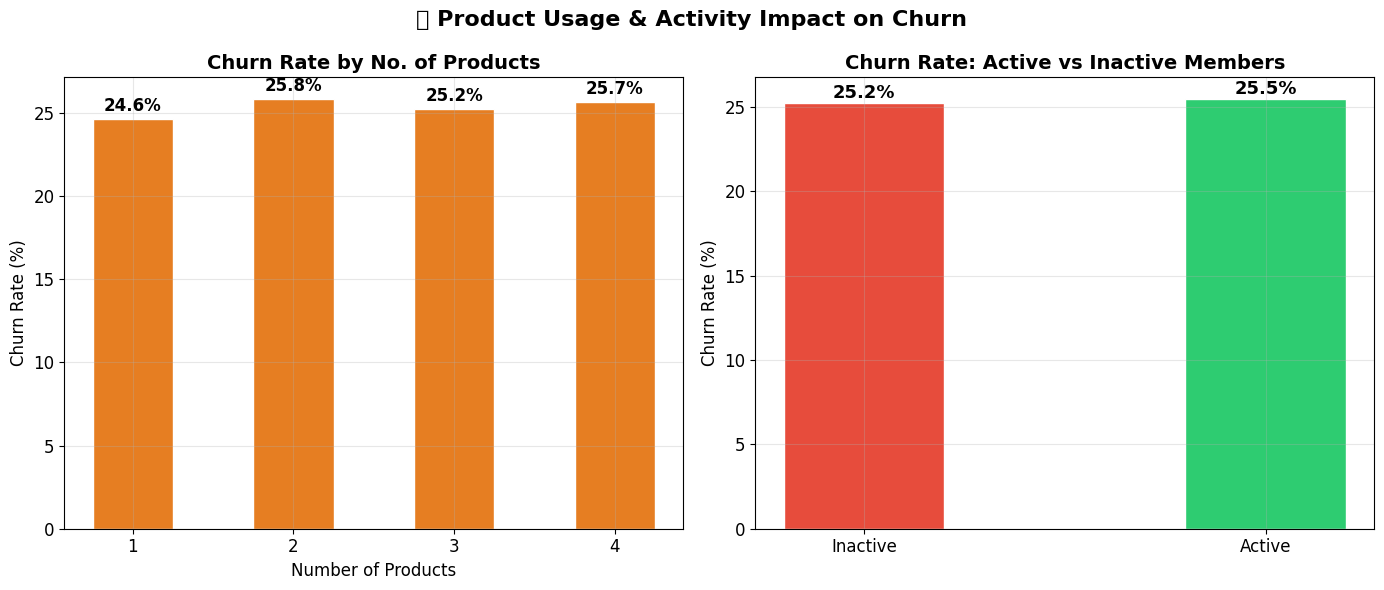

✅ Saved: churn_products.png


In [19]:
# Chart 4 — Products aur Active Member analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Products vs churn
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
bar_colors = ['#2ecc71' if v < 20 else '#e67e22' if v < 50 else '#e74c3c'
              for v in prod_churn.values]
bars = axes[0].bar(prod_churn.index.astype(str), prod_churn.values,
                   color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, prod_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by No. of Products', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')

# Active member vs churn
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
bars2 = axes[1].bar(active_churn.index, active_churn.values,
                    color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.4)
for bar, val in zip(bars2, active_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Churn Rate: Active vs Inactive Members', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

plt.suptitle('📦 Product Usage & Activity Impact on Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_products.png')

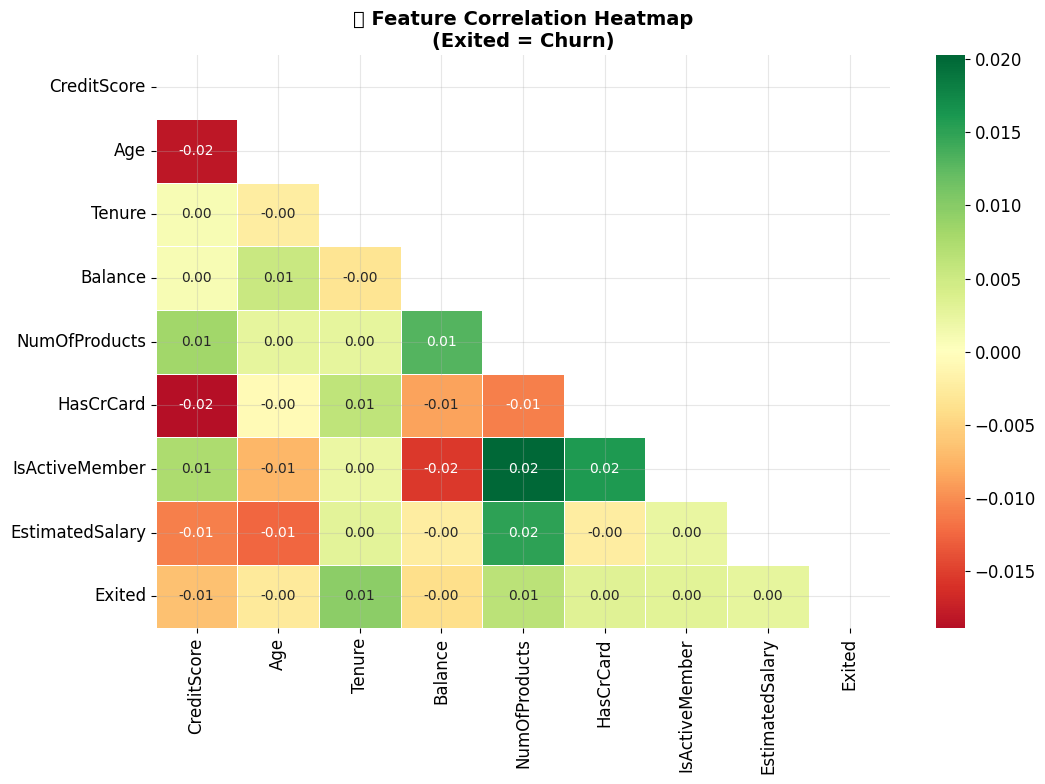

✅ Saved: churn_correlation.png


In [20]:
# Chart 5 — Correlation heatmap (numeric features)
numeric_cols = ['CreditScore','Age','Tenure','Balance',
                'NumOfProducts','HasCrCard','IsActiveMember',
                'EstimatedSalary','Exited']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('🌡️ Feature Correlation Heatmap\n(Exited = Churn)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_correlation.png')

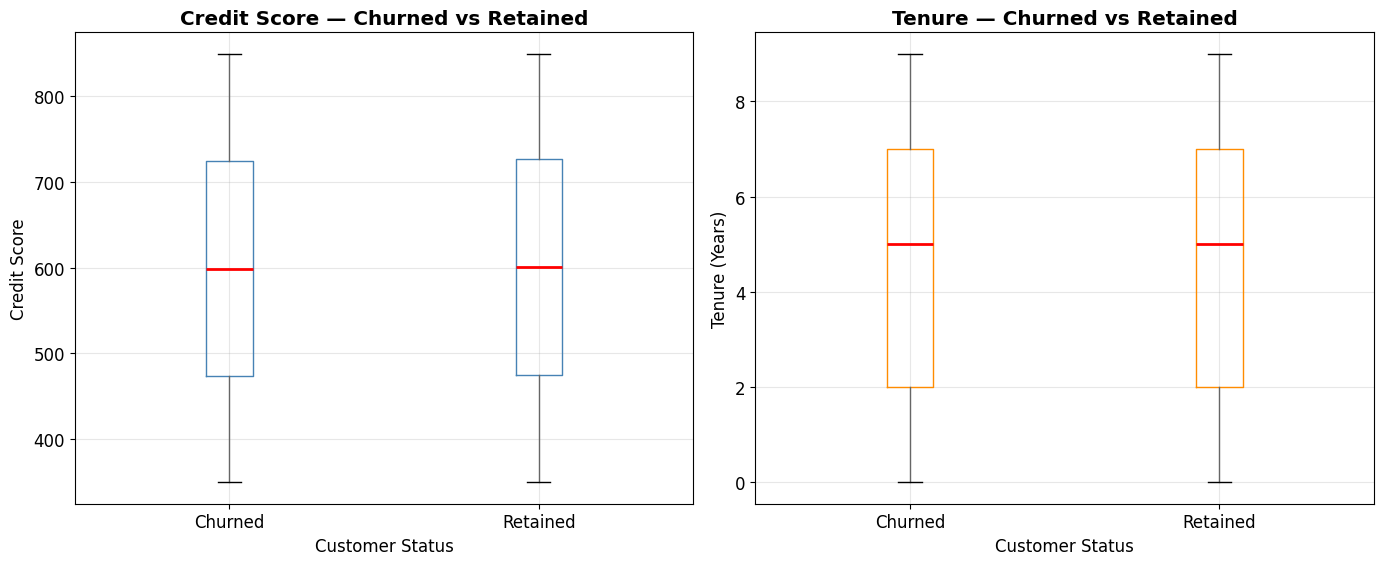

✅ Saved: churn_boxplots.png


In [21]:
# Chart 6 — Credit Score aur Tenure boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Credit score boxplot
df.boxplot(column='CreditScore', by='Churn_Label', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Credit Score — Churned vs Retained', fontweight='bold')
axes[0].set_xlabel('Customer Status')
axes[0].set_ylabel('Credit Score')
plt.sca(axes[0])
plt.title('Credit Score — Churned vs Retained', fontweight='bold')

# Tenure boxplot
df.boxplot(column='Tenure', by='Churn_Label', ax=axes[1],
           boxprops=dict(color='darkorange'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Tenure — Churned vs Retained', fontweight='bold')
axes[1].set_xlabel('Customer Status')
axes[1].set_ylabel('Tenure (Years)')
plt.sca(axes[1])
plt.title('Tenure — Churned vs Retained', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.savefig('churn_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: churn_boxplots.png')

## ✅ Step 6 — Final Summary & Key Insights

In [22]:
churn_rate   = df['Exited'].mean() * 100
top_country  = df.groupby('Geography')['Exited'].mean().idxmax()
top_gender   = df.groupby('Gender')['Exited'].mean().idxmax()
top_age      = df.groupby('Age_Group', observed=True)['Exited'].mean().idxmax()
risky_prod   = df.groupby('NumOfProducts')['Exited'].mean().idxmax()

print('=' * 55)
print('       📊 FINAL INSIGHTS & BUSINESS RECOMMENDATIONS')
print('=' * 55)
print(f"""
📌 KEY FINDINGS:
──────────────────────────────────────────────────
1. Overall Churn Rate    : {churn_rate:.1f}% customers ne bank chhoda
2. Highest Churn Country : {top_country} — sabse zyada churn yahan hai
3. Gender Impact         : {top_gender} customers zyada churn karte hain
4. Risky Age Group       : {top_age} age group mein churn sabse zyada
5. Product Risk          : {risky_prod} products wale customers sabse zyada churn karte hain
6. Inactive members      : Active members ke mukable zyada churn karte hain

💡 BUSINESS RECOMMENDATIONS:
──────────────────────────────────────────────────
1. {top_country} mein targeted retention campaigns chalao
2. Older age customers (46-55+) ke liye special offers do
3. Inactive members ko re-engage karo — loyalty programs
4. 3-4 products wale customers pe focus karo — high risk
5. High balance customers jo churn kar rahe hain —
   personalized relationship manager assign karo
""")

print('\n📁 Charts saved:')
for f in ['churn_overview','churn_demographics','churn_financial',
          'churn_products','churn_correlation','churn_boxplots']:
    print(f'   ✅ {f}.png')

       📊 FINAL INSIGHTS & BUSINESS RECOMMENDATIONS

📌 KEY FINDINGS:
──────────────────────────────────────────────────
1. Overall Churn Rate    : 25.4% customers ne bank chhoda
2. Highest Churn Country : Germany — sabse zyada churn yahan hai
3. Gender Impact         : Female customers zyada churn karte hain
4. Risky Age Group       : 46-55 age group mein churn sabse zyada
5. Product Risk          : 2 products wale customers sabse zyada churn karte hain
6. Inactive members      : Active members ke mukable zyada churn karte hain

💡 BUSINESS RECOMMENDATIONS:
──────────────────────────────────────────────────
1. Germany mein targeted retention campaigns chalao
2. Older age customers (46-55+) ke liye special offers do
3. Inactive members ko re-engage karo — loyalty programs
4. 3-4 products wale customers pe focus karo — high risk
5. High balance customers jo churn kar rahe hain —
   personalized relationship manager assign karo


📁 Charts saved:
   ✅ churn_overview.png
   ✅ churn_demographi

In [24]:
# The file 'Bank_Customer_Churn_Analysis.ipynb' was not found on the local disk.
# To download this notebook, please use 'File -> Download -> .ipynb' from the Colab menu.
# If you intend to download a specific file created in this session, ensure it exists with the correct filename.